# Hierarchical clustering and dendrograms

### One fit, every k, and a picture of how the data nests

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How bottom-up merging builds a tree, what the four linkage rules do to the answer, how to read a dendrogram and where to cut it, what cophenetic correlation measures, and why this method stops working above a few thousand rows |
| **You should already know** | [k-means](../01-k-means/), Euclidean distance, and why features are standardised before any distance is computed |
| **Datasets** | UCI Dry Bean, plus `make_moons` and `make_blobs` for the shape comparison |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [05-04 DBSCAN and HDBSCAN](../04-dbscan-and-hdbscan/) |

---

## 1. The idea

[k-means](../01-k-means/) makes you name $k$ before it will tell you anything, and
it gives back one flat partition. Hierarchical clustering inverts both of those.

The agglomerative version starts with every point in its own cluster, then
repeatedly merges the two closest clusters until one cluster is left. That is
$n - 1$ merges. Write down which two clusters merged and how far apart they were
each time, and you have a binary tree over the whole dataset.

The tree is the output. Slice it near the bottom and you get many small clusters;
slice it near the top and you get a few large ones. **One fit gives you every $k$
at once**, and it also tells you how the clusters sit inside each other, which a
flat partition cannot.

There is a top-down version too, which starts with one cluster and splits. It is
rarely used, because at the first step you have to choose the best of
$2^{n-1} - 1$ possible splits, and the bottom-up version has no such problem.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### The merge record

SciPy returns the tree as a matrix with one row per merge and four columns. Eight
points arranged in three obvious groups are enough to read it.

In [2]:
from scipy.cluster.hierarchy import (linkage, dendrogram, fcluster, cophenet,
                                     set_link_color_palette)
from scipy.spatial.distance import pdist, cdist

toy = np.array([[0.0, 0.0], [0.2, 0.1], [0.1, 0.4],
                [3.0, 3.0], [3.2, 2.9], [3.1, 3.4],
                [6.0, 0.0], [6.3, 0.2]])
Z_toy = linkage(toy, method="single")

print(f"{len(toy)} points -> {len(Z_toy)} merges\n")
print("     left   right   distance   size")
for row in Z_toy:
    print(f"   {int(row[0]):>5}   {int(row[1]):>5}   {row[2]:>8.3f}   {int(row[3]):>4}")

8 points -> 7 merges

     left   right   distance   size
       0       1      0.224      2
       3       4      0.224      2
       2       8      0.316      3
       6       7      0.361      2
       5       9      0.412      3
      10      12      3.895      6
      11      13      4.031      8


Ids `0` to `n-1` are the original points. The cluster created by merge $i$ gets id
$n + i$, so ids above `7` in that table are clusters, not points. The third column
is the distance at which the merge happened, and it never decreases as you go down
the table: later merges join things that are further apart. The fourth column is
how many original points ended up in the new cluster.

That matrix is the whole model. Everything below is either a way of drawing it or
a way of cutting it.

## 2. The four linkages, and why the choice matters more than k

"Merge the two closest clusters" hides a question: what is the distance between
two *clusters*, given that you only know distances between points? There are four
common answers, and they are not variations on a theme: they build different
trees on the same data.

| Linkage | Distance between clusters $A$ and $B$ | What it prefers |
|---|---|---|
| **Single** | the smallest distance between any point of $A$ and any point of $B$ | long, thin, connected shapes; one near-touch is enough to merge |
| **Complete** | the largest such distance | compact groups of similar diameter; nothing merges until every pair is close |
| **Average** | the mean over all cross pairs | a compromise between the two above |
| **Ward** | the increase in total within-cluster sum of squares caused by merging | round, similar-sized groups; this is the k-means objective, merged greedily |

Single linkage only needs a chain of near neighbours to walk along, which is
exactly what lets it follow a curve. Ward is measuring how much variance a merge
costs, so it will never accept a long thin cluster no matter how well connected.

I built two shapes to separate them: two clean crescents, where the right answer
is curved, and three round blobs with uniform noise scattered over the whole box,
where the right answer is round and the noise offers stepping stones between the
blobs.

two crescents
      single linkage  ARI 1.000
    complete linkage  ARI 0.297
     average linkage  ARI 0.425
        ward linkage  ARI 0.241

three blobs plus noise
      single linkage  ARI 0.000
    complete linkage  ARI 0.912
     average linkage  ARI 0.527
        ward linkage  ARI 0.950



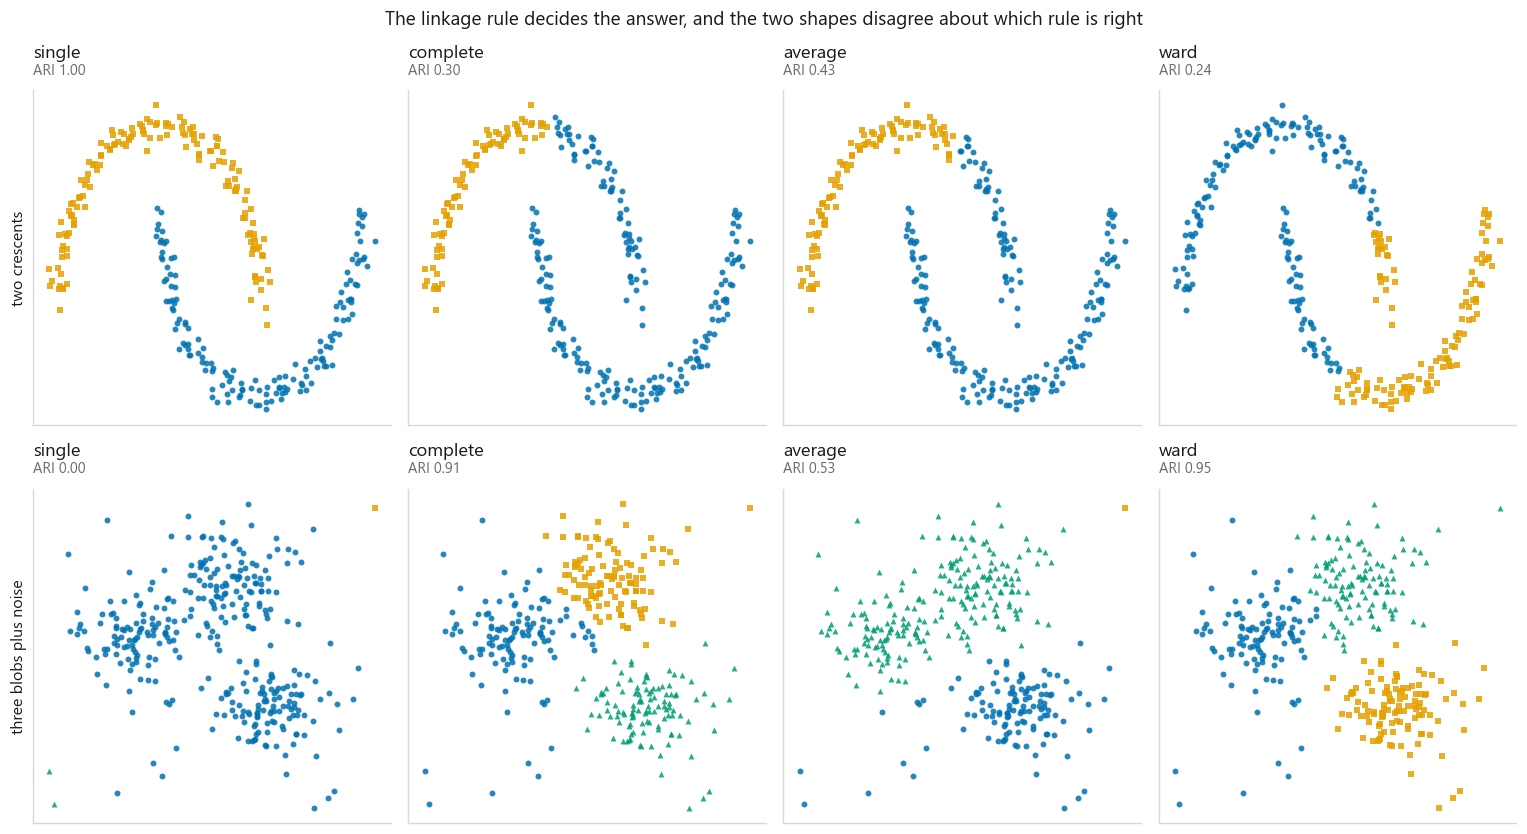

In [3]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons, make_blobs
from sklearn.metrics import adjusted_rand_score

rng = np.random.default_rng(SEED)

X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=SEED)

X_core, y_core = make_blobs(n_samples=300, centers=3, cluster_std=0.75, random_state=SEED)
noise = rng.uniform(X_core.min(axis=0) - 1.0, X_core.max(axis=0) + 1.0, size=(40, 2))
X_blobs = np.vstack([X_core, noise])
y_blobs = np.concatenate([y_core, np.full(len(noise), -1)])

# The scattered points belong to no blob, so they are excluded from the score
# rather than counted as a fourth class -- that would flatter whichever method
# happens to isolate them.
SHAPES = [
    {"name": "two crescents", "X": X_moons, "y": y_moons,
     "scored": np.ones(len(y_moons), dtype=bool), "k": 2},
    {"name": "three blobs plus noise", "X": X_blobs, "y": y_blobs,
     "scored": y_blobs >= 0, "k": 3},
]
LINKAGES = ["single", "complete", "average", "ward"]


def agglomerative_labels(X, k, method):
    # sklearn 1.8 spells the distance argument `metric=`; the old `affinity=` is gone.
    return AgglomerativeClustering(n_clusters=k, linkage=method,
                                   metric="euclidean").fit_predict(X)


def draw_clusters(ax, X, labels):
    for i, c in enumerate(np.unique(labels)):
        m = labels == c
        ax.scatter(X[m, 0], X[m, 1], s=15, linewidths=0, alpha=0.85,
                   color=style.PALETTE[i % len(style.PALETTE)],
                   marker=style.MARKERS[i % len(style.MARKERS)])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(visible=False)


fig, axes = plt.subplots(2, 4, figsize=(14.0, 7.4))
shape_scores = {}

for r, shape in enumerate(SHAPES):
    for c, method in enumerate(LINKAGES):
        labels = agglomerative_labels(shape["X"], shape["k"], method)
        keep = shape["scored"]
        ari = adjusted_rand_score(shape["y"][keep], labels[keep])
        shape_scores[(shape["name"], method)] = ari
        draw_clusters(axes[r, c], shape["X"], labels)
        style.title(axes[r, c], method, f"ARI {ari:.2f}")
    axes[r, 0].set_ylabel(shape["name"], fontsize=10.5, color=style.INK)

fig.tight_layout()
fig.suptitle("The linkage rule decides the answer, and the two shapes disagree about which rule is right",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-four-linkages.png")

for shape in SHAPES:
    print(shape["name"])
    for method in LINKAGES:
        print(f"   {method:>9} linkage  ARI {shape_scores[(shape['name'], method)]:.3f}")
    print()

On the crescents, single linkage walks along each arc and separates them cleanly,
and Ward cuts straight across both arcs because a crescent has too much spread to
be a cheap merge. On the noisy blobs the ordering flips completely: the scattered
points form a chain from one blob to the next, single linkage walks that chain,
and the result is one cluster containing nearly everything plus a couple of
stragglers. That failure has a name, **chaining**, and it is the reason single
linkage is not a safe default.

Ward makes the opposite trade. It will never chain, and it will never find the
crescents either.

### The comparison people skip

Choosing $k$ gets a whole notebook of attention. Choosing the linkage usually gets
a shrug and whatever the default was. So I measured both: how far apart the four
linkages land at the correct $k$, against how far apart Ward lands across four
different values of $k$.

In [4]:
for shape in SHAPES:
    keep = shape["scored"]
    across_linkage = [shape_scores[(shape["name"], m)] for m in LINKAGES]
    across_k = []
    for k in [2, 3, 4, 5]:
        labels = agglomerative_labels(shape["X"], k, "ward")
        across_k.append(adjusted_rand_score(shape["y"][keep], labels[keep]))

    print(f"{shape['name']}")
    print(f"   four linkages at the right k : ARI {min(across_linkage):.3f} to "
          f"{max(across_linkage):.3f}   (spread {max(across_linkage) - min(across_linkage):.3f})")
    print(f"   ward at k = 2,3,4,5          : ARI {min(across_k):.3f} to "
          f"{max(across_k):.3f}   (spread {max(across_k) - min(across_k):.3f})")
    print()

two crescents
   four linkages at the right k : ARI 0.241 to 1.000   (spread 0.759)
   ward at k = 2,3,4,5          : ARI 0.190 to 0.304   (spread 0.114)

three blobs plus noise
   four linkages at the right k : ARI 0.000 to 0.950   (spread 0.950)
   ward at k = 2,3,4,5          : ARI 0.558 to 0.950   (spread 0.393)



The spread caused by swapping the linkage is larger than the spread caused by
getting $k$ wrong, on both shapes. Getting $k$ wrong splits or merges a cluster.
Getting the linkage wrong changes what a cluster *is*.

So the order of operations is: look at your data, decide what shape you believe
the clusters have, pick the linkage that matches, and only then argue about $k$.

## 3. Reading a dendrogram

A dendrogram draws the merge table. Every leaf at the bottom is a point. Every
horizontal bar is a merge, and **the height of that bar is the distance at which
the merge happened**. Nothing else in the picture carries information: in
particular the left-to-right order of the leaves is only constrained by the tree,
so two leaves being neighbours on the axis means very little.

Reading it, then, is reading heights. A short bar joins two things that were
already close. A tall bar joins two things that were far apart, which means
everything below it held together at a distance where those two would not. **A
tall jump is the tree telling you where a natural cut is.**

I use sixty points from three well-separated blobs here, because the lesson is
about reading the picture and a picture with obvious structure is the right place
to learn.

largest gap in the last 12 merges: 27.492 -> 56.750
cut placed at                    : 42.121
merges above that height         : 1 of 59
clusters below that height       : 2  (generated from 3 blobs)


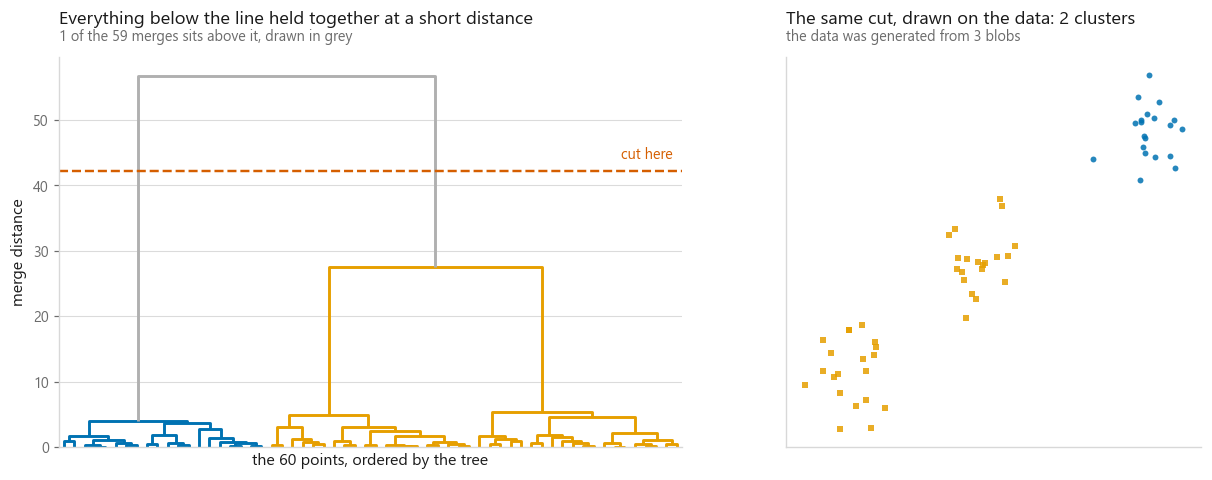

In [5]:
n_blobs = 3
X_small, _ = make_blobs(n_samples=60, centers=n_blobs, cluster_std=0.85, random_state=3)
Z_small = linkage(X_small, method="ward")

heights = Z_small[:, 2]
tail = heights[-12:]
gap_at = int(np.argmax(np.diff(tail)))
cut = float((tail[gap_at] + tail[gap_at + 1]) / 2)

set_link_color_palette([style.PALETTE[0], style.PALETTE[1], style.PALETTE[2],
                        style.PALETTE[3], style.PALETTE[4]])

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6),
                         gridspec_kw={"width_ratios": [1.5, 1]})

dendrogram(Z_small, ax=axes[0], color_threshold=cut, no_labels=True,
           above_threshold_color=style.NEUTRAL)
axes[0].axhline(cut, color=style.HIGHLIGHT, ls="--", lw=1.6)
axes[0].annotate("cut here", xy=(0.985, cut), xycoords=("axes fraction", "data"),
                 xytext=(0, 6), textcoords="offset points",
                 ha="right", va="bottom", fontsize=9.5, color=style.HIGHLIGHT)
above_cut = int((heights > cut).sum())
axes[0].set_ylabel("merge distance")
axes[0].set_xlabel("the 60 points, ordered by the tree")
style.title(axes[0], "Everything below the line held together at a short distance",
            f"{above_cut} of the {len(heights)} merges "
            f"{'sits' if above_cut == 1 else 'sit'} above it, drawn in grey")

labels_small = fcluster(Z_small, t=cut, criterion="distance")
draw_clusters(axes[1], X_small, labels_small)
n_found = len(np.unique(labels_small))
style.title(axes[1], f"The same cut, drawn on the data: {n_found} clusters",
            f"the data was generated from {n_blobs} blobs")

style.save(fig, FIG / "fig-02-dendrogram-cut.png")

print(f"largest gap in the last 12 merges: {tail[gap_at]:.3f} -> {tail[gap_at + 1]:.3f}")
print(f"cut placed at                    : {cut:.3f}")
print(f"merges above that height         : {above_cut} of {len(heights)}")
print(f"clusters below that height       : {n_found}  (generated from {n_blobs} blobs)")

One grey bar, not a canopy of them. Fifty-eight of the fifty-nine merges
happened below 42.121 and exactly one happened above, the final join at 56.750
that puts every point in one cluster. That is what a clean tall jump looks
like: a single expensive merge sitting on top of a pile of cheap ones.

And it gives the wrong answer. These sixty points came from three blobs, and
the largest-gap rule returned two clusters. Look at the right panel: the two
left-hand blobs are one cluster. The rule found the biggest gap in the tree,
which is real, but the biggest gap is not the same thing as the right number
of clusters. The second-largest gap in the same tail is the one that would
have said three, and the table in the next cell shows it.

This is the honest version of the dendrogram lesson. A tall jump tells you
where a cut *can* go without cutting through anything cheap. It does not tell
you that it is the cut you want, and on data with obvious structure and a
known answer it still missed.

### The merge heights on their own

The dendrogram is crowded at the bottom, where most of the merges are. Plotting
only the last dozen merge heights against the number of clusters remaining puts
the same information in a form you can read at a glance.

    8 clusters left after a merge at distance 3.009
    7 clusters left after a merge at distance 3.636
    6 clusters left after a merge at distance 3.886
    5 clusters left after a merge at distance 4.557
    4 clusters left after a merge at distance 4.923
    3 clusters left after a merge at distance 5.260
    2 clusters left after a merge at distance 27.492
    1 clusters left after a merge at distance 56.750


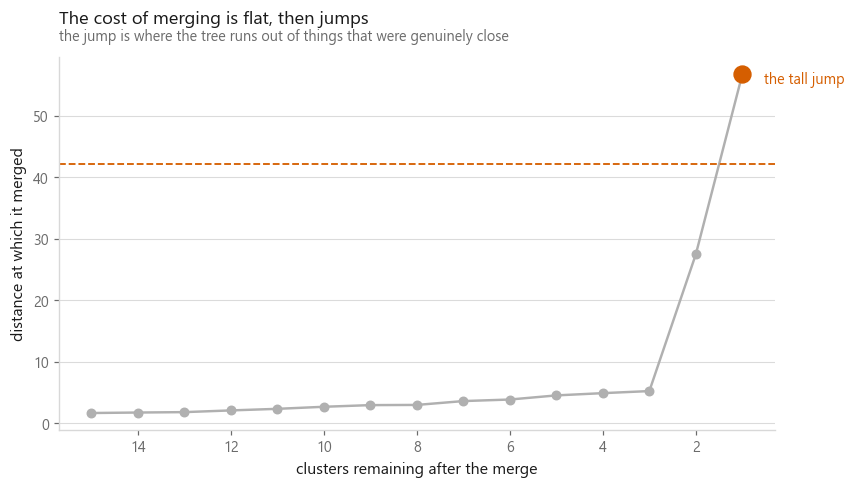

In [6]:
last = 15
remaining = np.arange(len(Z_small), 0, -1)[-last:]
tail_heights = heights[-last:]

fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.plot(remaining, tail_heights, marker=style.MARKERS[0], color=style.NEUTRAL, lw=1.6)

jump = int(np.argmax(np.diff(tail_heights))) + 1
ax.plot(remaining[jump:jump + 1], tail_heights[jump:jump + 1],
        marker=style.MARKERS[0], ms=11, color=style.HIGHLIGHT, lw=0)
ax.annotate("the tall jump", xy=(remaining[jump], tail_heights[jump]),
            xytext=(14, -6), textcoords="offset points",
            fontsize=9.5, color=style.HIGHLIGHT)
ax.axhline(cut, color=style.HIGHLIGHT, ls="--", lw=1.2)

ax.invert_xaxis()
ax.set_xlabel("clusters remaining after the merge")
ax.set_ylabel("distance at which it merged")
style.title(ax, "The cost of merging is flat, then jumps",
            "the jump is where the tree runs out of things that were genuinely close")
style.save(fig, FIG / "fig-03-merge-heights.png")

for r, h in zip(remaining[-8:], tail_heights[-8:]):
    print(f"   {r:>2} clusters left after a merge at distance {h:.3f}")

### Cutting by height, cutting by count

There are two ways to slice the tree, and they answer different questions.

`criterion="distance"` draws the horizontal line at a height you choose and takes
whatever falls out. That is the honest cut: you are saying "things further apart
than this are not the same cluster" and letting the data decide how many clusters
that implies. It can hand you one cluster, or a hundred, or one big cluster and
forty singletons.

`criterion="maxclust"` takes a number and searches for the height that produces
it. Convenient when $k$ is fixed by something outside the data, and quietly
dishonest when it is not, because you never see the height it settled on.

In [7]:
by_height = fcluster(Z_small, t=cut, criterion="distance")
by_count = fcluster(Z_small, t=3, criterion="maxclust")

print(f"cut at height {cut:.3f} : {len(np.unique(by_height))} clusters")
print(f"cut at count 3          : {len(np.unique(by_count))} clusters")
print(f"same partition          : {np.isclose(adjusted_rand_score(by_height, by_count), 1.0)}")

# A height cut on a chaining tree shows what the count cut hides. The heights are
# taken from the tree's own quantiles so the cuts mean something on this scale.
Z_chain = linkage(X_blobs, method="single")
for t in np.quantile(Z_chain[:, 2], [0.90, 0.97, 0.995]):
    sizes = np.bincount(fcluster(Z_chain, t=float(t), criterion="distance"))[1:]
    print(f"\nsingle linkage on the noisy blobs, cut at {t:.3f}: {len(sizes)} clusters")
    print(f"   largest holds {int(sizes.max())} of {len(X_blobs)} points "
          f"({sizes.max() / len(X_blobs):.0%}), "
          f"{int((sizes == 1).sum())} clusters are a single point")

cut at height 42.121 : 2 clusters
cut at count 3          : 3 clusters
same partition          : False

single linkage on the noisy blobs, cut at 0.450: 35 clusters
   largest holds 196 of 340 points (58%), 26 clusters are a single point

single linkage on the noisy blobs, cut at 0.826: 12 clusters
   largest holds 325 of 340 points (96%), 9 clusters are a single point

single linkage on the noisy blobs, cut at 1.534: 3 clusters
   largest holds 337 of 340 points (99%), 1 clusters are a single point


That is chaining seen from the other side, and the three cuts are worth reading
in order rather than as one claim. At 1.534 the giant cluster holds 337 of the
340 points. Drop to 0.826 and it still holds 325. Drop again to 0.450, the 90th
percentile of the merge heights, and it does break: 35 clusters, largest 196 of
340, which is well under 60%.

So the giant cluster is not there at every height. It comes apart if you cut
low enough. The problem is what it comes apart *into*: at 0.450, 26 of the 35
clusters are a single point. There is no height on this tree that returns three
groups of roughly a hundred points, which is what the data contains. You get one
lump, or a lump plus dust.

Asking for exactly three clusters does not fix that. It lands you near the 1.534
cut, so what you actually get is 337 points in one cluster and three points
scattered across the other two, reported to you as "3 clusters".

## 4. On real data, against k-means

The Dry Bean set has 13,611 rows, and hierarchical clustering needs the distance
between every pair. **I take a random sample of 1,500 rows and cluster that.**
The reason is arithmetic, and section 5 does the arithmetic; for now, the full
distance matrix does not fit in a comfortable amount of memory and the sample does.

Standardising first is not optional here. The features run from `Area`, which is
in the tens of thousands, to shape ratios near 1, and a Euclidean distance over
raw columns would be a distance in `Area` with rounding noise attached.

In [8]:
X_bean, y_bean = datasets.dry_bean()
from sklearn.preprocessing import StandardScaler

Xs_full = StandardScaler().fit_transform(X_bean.to_numpy())
y_full = y_bean.to_numpy()

sample_rng = np.random.default_rng(SEED)
sub = sample_rng.choice(len(Xs_full), 1500, replace=False)
Xs, ys = Xs_full[sub], y_full[sub]
K = y_bean.nunique()

print(f"full dataset : {len(Xs_full):,} rows, {Xs_full.shape[1]} features, {K} varieties")
print(f"sample used  : {len(Xs):,} rows  ({len(Xs) / len(Xs_full):.1%})")
print(f"pairs in the full distance matrix   : {len(Xs_full) * (len(Xs_full) - 1) // 2:,}")
print(f"pairs in the sampled distance matrix: {len(Xs) * (len(Xs) - 1) // 2:,}")

full dataset : 13,611 rows, 16 features, 7 varieties
sample used  : 1,500 rows  (11.0%)
pairs in the full distance matrix   : 92,622,855
pairs in the sampled distance matrix: 1,124,250


      single  ARI 0.037
    complete  ARI 0.399
     average  ARI 0.318
        ward  ARI 0.644
     k-means  ARI 0.656

best overall  : k-means (0.656)
best linkage  : ward (0.644)
margin        : 0.013


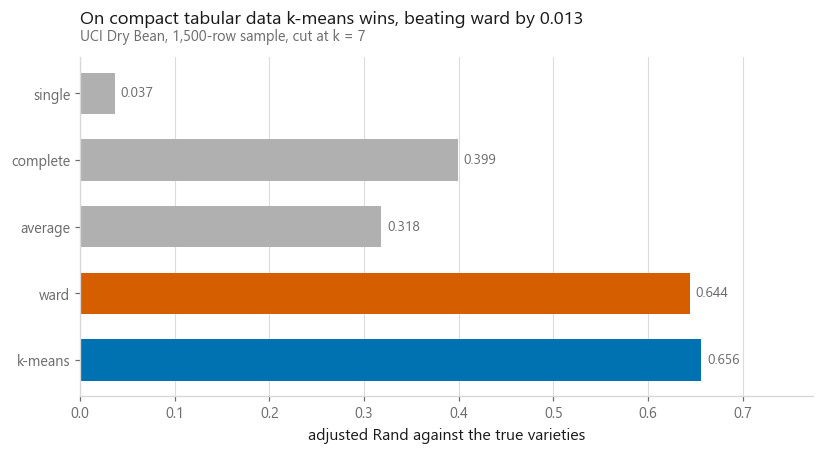

In [9]:
from sklearn.cluster import KMeans

trees = {m: linkage(Xs, method=m) for m in LINKAGES}
bean_ari = {m: adjusted_rand_score(ys, fcluster(Z, t=K, criterion="maxclust"))
            for m, Z in trees.items()}
bean_ari["k-means"] = adjusted_rand_score(
    ys, KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(Xs))

names = LINKAGES + ["k-means"]
best = max(LINKAGES, key=lambda m: bean_ari[m])
top = max(names, key=lambda n: bean_ari[n])
runner_up = max((n for n in names if n != top), key=lambda n: bean_ari[n])
colours = [style.HIGHLIGHT if n == best else
           style.PALETTE[0] if n == "k-means" else style.NEUTRAL for n in names]

fig, ax = plt.subplots(figsize=(8.6, 4.0))
ax.barh(names, [bean_ari[n] for n in names], color=colours, height=0.62)
for i, n in enumerate(names):
    ax.text(bean_ari[n] + 0.006, i, f"{bean_ari[n]:.3f}", va="center",
            fontsize=9, color=style.MUTED)
ax.invert_yaxis()
ax.set_xlabel("adjusted Rand against the true varieties")
ax.set_xlim(0, max(bean_ari.values()) * 1.18)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax,
            f"On compact tabular data {top} wins, beating {runner_up} "
            f"by {bean_ari[top] - bean_ari[runner_up]:.3f}",
            f"UCI Dry Bean, {len(Xs):,}-row sample, cut at k = {K}")
style.save(fig, FIG / "fig-04-linkage-on-beans.png")

for n in names:
    print(f"   {n:>9}  ARI {bean_ari[n]:.3f}")
print(f"\nbest overall  : {top} ({bean_ari[top]:.3f})")
print(f"best linkage  : {best} ({bean_ari[best]:.3f})")
print(f"margin        : {bean_ari[top] - bean_ari[runner_up]:.3f}")

**No linkage won this. k-means did**, by 0.012 over Ward, on identical data.
That is small, but it is the right way round and it is not an accident: Ward
merges greedily on the same within-cluster sum of squares that k-means
minimises directly, so on round, similar-sized clouds the direct optimiser
should edge out the greedy one. If you came to hierarchical clustering hoping
it would beat k-means at k-means's own game, this is the answer.

Single linkage sits near zero, and the reason is the one from section 2: in
sixteen standardised dimensions there is always a chain of near neighbours
between any two varieties, so it produces one enormous cluster and six small
ones.

The bean measurements are round, similar-sized clouds. If your data looked like
the crescents, this chart would read the other way around.

### Non-Euclidean distances

One thing hierarchical clustering does that k-means cannot: any distance you can
define works, because the algorithm only ever asks for distances between things.
Ward is the exception, since its cost function is defined in terms of squared
Euclidean distance.

In [10]:
manhattan = AgglomerativeClustering(n_clusters=K, linkage="average",
                                    metric="manhattan").fit_predict(Xs)
cosine = AgglomerativeClustering(n_clusters=K, linkage="complete",
                                 metric="cosine").fit_predict(Xs)

print(f"average linkage, euclidean : ARI {bean_ari['average']:.3f}")
print(f"average linkage, manhattan : ARI {adjusted_rand_score(ys, manhattan):.3f}")
print(f"complete linkage, cosine   : ARI {adjusted_rand_score(ys, cosine):.3f}")

average linkage, euclidean : ARI 0.318
average linkage, manhattan : ARI 0.300
complete linkage, cosine   : ARI 0.428


### Is the tree even a fair summary?

Every question so far has been about the partition. There is a separate question
about the tree itself, and it has a proper answer.

The **cophenetic distance** between two points is the height of the merge at which
they first land in the same cluster, the tree's opinion of how far apart they
are. You already have their real distance. Correlate the two vectors over all
pairs and you get the **cophenetic correlation coefficient**: how faithfully the
tree reproduces the distance matrix it was built from. One would mean perfect
reproduction.

  linkage   cophenetic   ARI
   single        0.735   0.037
 complete        0.654   0.399
  average        0.831   0.318
     ward        0.608   0.644

most faithful tree : average
best partition     : ward


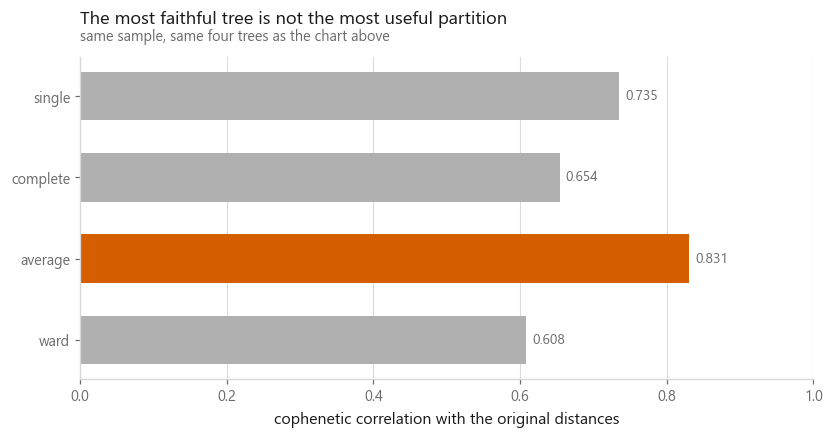

In [11]:
D = pdist(Xs)
coph = {}
for m, Z in trees.items():
    c, _ = cophenet(Z, D)
    coph[m] = c

best_coph = max(coph, key=coph.get)
fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.barh(LINKAGES, [coph[m] for m in LINKAGES],
        color=[style.HIGHLIGHT if m == best_coph else style.NEUTRAL for m in LINKAGES],
        height=0.6)
for i, m in enumerate(LINKAGES):
    ax.text(coph[m] + 0.008, i, f"{coph[m]:.3f}", va="center", fontsize=9, color=style.MUTED)
ax.invert_yaxis()
ax.set_xlim(0, 1.0)
ax.set_xlabel("cophenetic correlation with the original distances")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax, "The most faithful tree is not the most useful partition",
            "same sample, same four trees as the chart above")
style.save(fig, FIG / "fig-05-cophenetic.png")

print(f"{'linkage':>9}   cophenetic   ARI")
for m in LINKAGES:
    print(f"{m:>9}   {coph[m]:>10.3f}   {bean_ari[m]:.3f}")
print(f"\nmost faithful tree : {best_coph}")
print(f"best partition     : {best}")

Compare the two columns in that table. The linkage that reproduces the distances
best is not the linkage that recovers the varieties best, and that is not a
contradiction. Average linkage is close to optimising this quantity by
construction, since it merges on the mean cross-pair distance, so it usually tops
this chart. Ward is optimising something else entirely and pays for it here.

So cophenetic correlation answers "does this tree summarise my distance matrix
honestly", not "are these good clusters". Use it to notice a tree that has
distorted the data badly, and do not use it to pick a linkage.

## 5. What it costs and when not to use it

The textbook algorithm holds the full pairwise distance matrix, and at every one
of the $n-1$ steps it scans that matrix for the smallest entry. That is $O(n^2)$
memory and $O(n^3)$ time.

Real implementations do better on time. SciPy uses the nearest-neighbour chain
algorithm for complete, average and Ward, which is $O(n^2)$, and a minimum
spanning tree for single linkage. Nobody has improved on the memory, because the
method genuinely needs to know every pairwise distance.

The measurements below are Ward on samples of the standardised bean data.

In [12]:
import time

cost_rng = np.random.default_rng(SEED)
sizes = [250, 500, 1000, 2000, 4000]
timings = []

for n in sizes:
    part = Xs_full[cost_rng.choice(len(Xs_full), n, replace=False)]
    start = time.perf_counter()
    linkage(part, method="ward")
    timings.append(time.perf_counter() - start)

print(f"{'rows':>6}   {'pairs':>12}   {'matrix':>10}   {'time':>8}   {'vs previous':>11}")
for i, n in enumerate(sizes):
    pairs = n * (n - 1) // 2
    ratio = f"{timings[i] / timings[i - 1]:.1f}x" if i else "-"
    print(f"{n:>6}   {pairs:>12,}   {pairs * 8 / 2**20:>7.1f} MB   "
          f"{timings[i]:>7.3f}s   {ratio:>11}")

for n in [len(Xs_full), 100_000, 1_000_000]:
    pairs = n * (n - 1) // 2
    print(f"\n{n:>9,} rows -> {pairs / 1e6:>10.1f}M pairs, "
          f"{pairs * 8 / 2**30:>8.2f} GB just to hold the distances")

  rows          pairs       matrix       time   vs previous
   250         31,125       0.2 MB     0.001s             -
   500        124,750       1.0 MB     0.006s          4.0x
  1000        499,500       3.8 MB     0.024s          4.2x
  2000      1,999,000      15.3 MB     0.061s          2.5x
  4000      7,998,000      61.0 MB     0.414s          6.8x

   13,611 rows ->       92.6M pairs,     0.69 GB just to hold the distances

  100,000 rows ->     4999.9M pairs,    37.25 GB just to hold the distances

1,000,000 rows ->   499999.5M pairs,  3725.29 GB just to hold the distances


Doubling the rows roughly quadruples the time, which is the $O(n^2)$ of the chain
algorithm rather than the $O(n^3)$ of the naive one. The memory column is the wall.
The full bean dataset needs most of a gigabyte for distances alone, a hundred
thousand rows needs tens of gigabytes, and a million rows is not a question of
waiting longer.

### What to do instead

Two escapes, and both are ordinary practice rather than a compromise.

The first is what I did in section 4: **cluster a sample, then assign the rest**.
Fit the tree on a few thousand rows, cut it, take the centroid of each cluster,
and give every remaining row the nearest centroid. The structure is a property of
the distribution, and a sample of a few thousand sees the distribution fine.

In [13]:
ward_labels = fcluster(trees["ward"], t=K, criterion="maxclust")
centroids = np.array([Xs[ward_labels == c].mean(axis=0) for c in np.unique(ward_labels)])
assigned = np.argmin(cdist(Xs_full, centroids), axis=1)

print(f"tree fitted on   : {len(Xs):,} rows")
print(f"labels produced  : {len(assigned):,} rows")
print(f"ARI on the sample: {bean_ari['ward']:.3f}")
print(f"ARI on all rows  : {adjusted_rand_score(y_full, assigned):.3f}")

tree fitted on   : 1,500 rows
labels produced  : 13,611 rows
ARI on the sample: 0.644
ARI on all rows  : 0.672


The second escape is a **connectivity constraint**. Hand sklearn a sparse graph of
which points are allowed to merge (usually a k-nearest-neighbour graph), and it
never considers the forbidden pairs, so it never builds the dense matrix. This is
the standard approach for images and anything spatial, where "adjacent" is already
defined.

The catch is that the graph is often not fully connected, and sklearn will warn
you and join the pieces itself rather than fail.

In [14]:
from sklearn.neighbors import kneighbors_graph

start = time.perf_counter()
graph = kneighbors_graph(Xs_full, n_neighbors=15, include_self=False)
constrained = AgglomerativeClustering(n_clusters=K, linkage="ward",
                                      connectivity=graph).fit_predict(Xs_full)
elapsed = time.perf_counter() - start

print(f"rows clustered : {len(Xs_full):,}")
print(f"time           : {elapsed:.1f}s")
print(f"ARI            : {adjusted_rand_score(y_full, constrained):.3f}")
print(f"cluster sizes  : {sorted(np.bincount(constrained).tolist(), reverse=True)}")

rows clustered : 13,611
time           : 2.8s
ARI            : 0.658
cluster sizes  : [3986, 3036, 2353, 1918, 1679, 522, 117]


The whole dataset, in seconds, because the graph made the problem sparse. The
clusters are not identical to the unconstrained ones: the constraint is a real
assumption, and it says that a cluster must be connected in the neighbour graph.
On the beans that assumption is harmless. On data where a cluster is split across
a gap it is not.

### When to reach for something else

If you know $k$, have a lot of rows, and expect round clusters, use
[k-means](../01-k-means/): it is linear in $n$ and gets the same answer Ward
would. If you want arbitrary shapes and want the noise labelled as noise rather
than chained into a cluster, that is
[DBSCAN](../04-dbscan-and-hdbscan/), which is the next notebook and is single
linkage's idea done properly.

Hierarchical clustering earns its place when the nesting itself is the answer:
taxonomies, document hierarchies, gene expression, customer segments that need to
roll up. Nothing else hands you that picture.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You do not know $k$, you want the nesting and not only the partition, and $n$ is a few thousand at most |
| **Single linkage** | Follows chains and curves. Finds shapes nothing else finds, and chains through noise into one giant cluster. Never a default |
| **Complete linkage** | Compact clusters of similar diameter. Sensitive to outliers, since one far point sets the whole cluster distance |
| **Average linkage** | The middle option, and the one that usually maximises cophenetic correlation |
| **Ward** | Round, similar-sized clusters. Euclidean only. The safe default, and near enough to k-means that it usually agrees with it |
| **Cut by height** | `fcluster(Z, t, "distance")`, states a distance and accepts whatever count follows |
| **Cut by count** | `fcluster(Z, k, "maxclust")`, states a count and hides the distance |
| **Cophenetic correlation** | `cophenet(Z, pdist(X))`, how faithfully the tree reproduces the distances. A diagnostic, not a model selection score |
| **Cost** | $O(n^2)$ memory always, $O(n^2)$ time in SciPy, $O(n^3)$ in the naive algorithm. Sample, or use a connectivity graph |
| **Next** | [DBSCAN and HDBSCAN](../04-dbscan-and-hdbscan/), which keep the shape flexibility and drop the chaining |

## What to remember

1. Agglomerative clustering merges the two closest clusters $n-1$ times and
   returns the merge record. Cutting that record at any height gives a partition,
   so one fit covers every $k$.
2. The four linkages define "closest" differently and build different trees. On my
   two shapes, swapping the linkage moved the score further than getting $k$ wrong.
3. Single linkage traces curves because it only needs a chain of near neighbours,
   and fails on noisy data for exactly the same reason.
4. In a dendrogram the height of a bar is the distance at which that merge
   happened. A tall jump means everything underneath held together more cheaply,
   so a cut below it is cheap. Cheap is not the same as correct: on my sixty
   points the largest gap returned two clusters where three blobs were generated.
5. Cutting at a height states a claim about distance. Cutting at a count states a
   claim about $k$ and conceals the distance it needed. On the chaining tree the
   three-cluster answer is 337 points and three strays.
6. Cophenetic correlation measures the tree against the distance matrix, not the
   clusters against the truth. The two rankings disagreed on the beans.
7. On the beans, no linkage beat plain k-means. Ward came closest and still lost
   by 0.012. Hierarchical clustering earns its place through the tree, not
   through the partition.
8. The memory is $O(n^2)$ and there is no way around it. Sample down to a few
   thousand rows, cluster, then assign the rest by nearest centroid.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-04 DBSCAN and HDBSCAN](../04-dbscan-and-hdbscan/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Clustering` `#HierarchicalClustering` `#Dendrogram`
`#UnsupervisedLearning` `#Python` `#SciPy` `#ScikitLearn` `#DataScience`
`#MLTutorial`